In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

!pip install segmentation-models-pytorch
from segmentation_models_pytorch.losses import DiceLoss
from segmentation_models_pytorch.losses import JaccardLoss
import torch.nn.functional as F

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 79.9 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 53.2 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 35.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 11.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.9 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: n

/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

In [2]:
# Import librerie essenziali per semantic segmentation con FCN su COCO
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models.segmentation as seg
from torchvision.models.segmentation import fcn_resnet50
import torch.nn.functional as F

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms.functional as TF
import random

from pycocotools.coco import COCO
import os
from tqdm import tqdm
import imageio.v2 as imageio

# Verifica disponibilità GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Path del subset COCO caricato su Kaggle 
ROOT_DIR = '/kaggle/input/coco-subset-complete'  
TRAIN_IMG_DIR = os.path.join(ROOT_DIR, 'train/images')
VAL_IMG_DIR = os.path.join(ROOT_DIR, 'validation/images')
TRAIN_ANN_FILE = os.path.join(ROOT_DIR, 'train/annotations.json')
VAL_ANN_FILE = os.path.join(ROOT_DIR, 'validation/annotations.json')

# Verifica che i file esistano
print(f"Train images exist: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Val images exist: {os.path.exists(VAL_IMG_DIR)}")
print(f"Train annotations exist: {os.path.exists(TRAIN_ANN_FILE)}")
print(f"Val annotations exist: {os.path.exists(VAL_ANN_FILE)}")

Train images exist: True
Val images exist: True
Train annotations exist: True
Val annotations exist: True


loading annotations into memory...
Done (t=2.06s)
creating index...
index created!
loading annotations into memory...
Done (t=0.24s)
creating index...
index created!


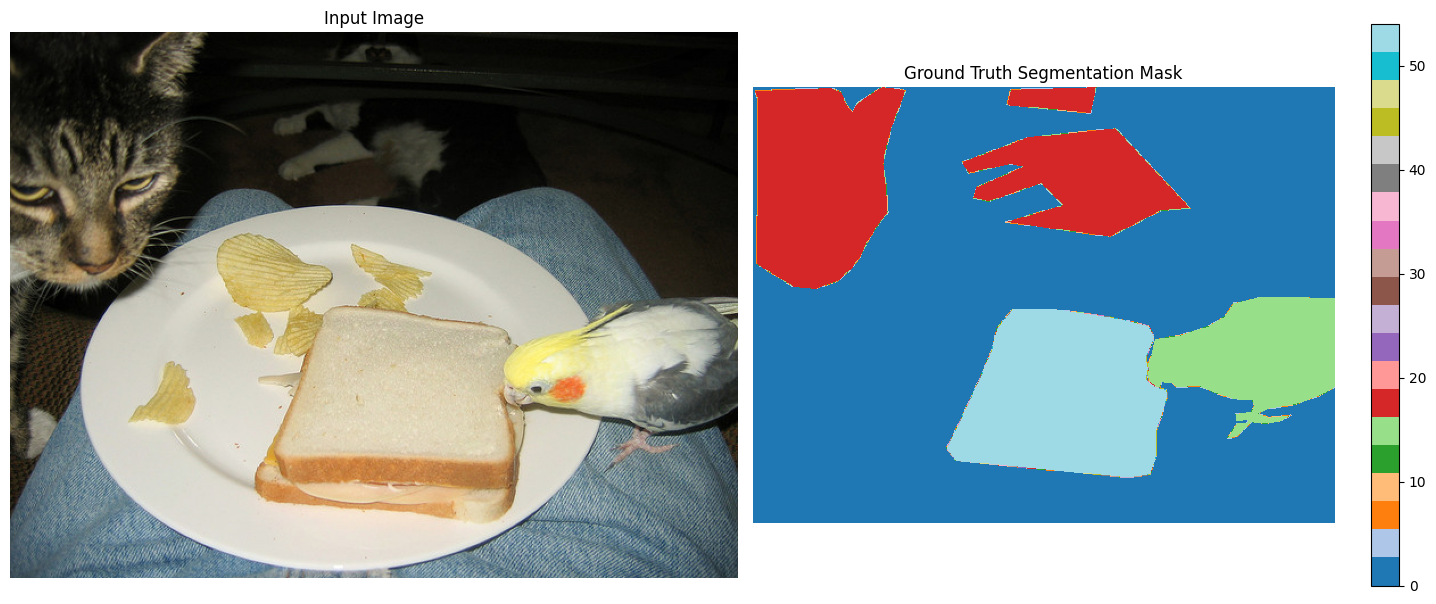

Image filename: 000000263623.jpg
Image shape: (480, 640, 3)
Mask shape: (480, 640)
Total train images in subset: 10000
Total val images in subset: 1353


In [4]:
# Visualizzazione di esempio dalle immagini del subset caricato
import imageio.v2 as imageio

# Carichiamo le annotazioni COCO del subset
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)

# Prendiamo la prima immagine dal  training set
img_ids = coco_train.getImgIds()
sample_img_id = img_ids[200]  # Prima immagine del subset



# Carica info immagine
img_info = coco_train.loadImgs(sample_img_id)[0]
img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])

# Carica immagine con imageio
image = imageio.imread(img_path)

# Carica annotazioni per questa immagine
ann_ids = coco_train.getAnnIds(imgIds=sample_img_id)
annotations = coco_train.loadAnns(ann_ids)
'''
# categorie presenti in questa immagine
cat_ids = [ann['category_id'] for ann in annotations]
print("Category IDs in this image:", cat_ids)

# controlla se c'è la classe 'person' (id 1)
print("Has person?", 1 in cat_ids)
'''
# Crea maschera di segmentazione
mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
for ann in annotations:
    binary_mask = coco_train.annToMask(ann)
    mask[binary_mask == 1] = ann['category_id']

# Visualizzazione affiancata
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
plt.imshow(image)
plt.title('Input Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='tab20')
plt.title('Ground Truth Segmentation Mask')
plt.axis('off')
plt.colorbar()
plt.tight_layout()
plt.show()

print(f"Image filename: {img_info['file_name']}")
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")
print(f"Total train images in subset: {len(img_ids)}")
print(f"Total val images in subset: {len(coco_val.getImgIds())}")

In [5]:
# Verifica che tutte le immagini abbiano annotations valide
print("\n🔍 Checking dataset integrity...")

no_annotations = []
corrupted = []

for img_id in tqdm(img_ids, desc="Checking"):  # Check primi 1000
    try:
        # Check annotations
        ann_ids = coco_train.getAnnIds(imgIds=img_id)
        if len(ann_ids) == 0:
            no_annotations.append(img_id)
            continue
        
        # Check se file esiste
        img_info = coco_train.loadImgs(img_id)[0]
        img_path = os.path.join(TRAIN_IMG_DIR, img_info['file_name'])
        if not os.path.exists(img_path):
            corrupted.append(img_id)
    except:
        corrupted.append(img_id)

print(f"\n✅ Images without annotations: {len(no_annotations)}")
print(f"✅ Corrupted/missing images: {len(corrupted)}")

if len(no_annotations) == 0 and len(corrupted) == 0:
    print("\n🎉 Dataset integrity check PASSED!")


🔍 Checking dataset integrity...


Checking: 100%|██████████| 10000/10000 [00:16<00:00, 592.84it/s]


✅ Images without annotations: 115
✅ Corrupted/missing images: 0


In [6]:
import json
from collections import defaultdict
import random

# Carica annotazioni
print("Caricamento annotazioni...")
coco_train = COCO(TRAIN_ANN_FILE)
coco_val = COCO(VAL_ANN_FILE)

# Raggruppa immagini per categoria
cat_to_imgs = defaultdict(list)
for img_id in coco_train.getImgIds():
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    if ann_ids:  # Solo immagini con annotazioni
        anns = coco_train.loadAnns(ann_ids)
        for ann in anns:
            cat_to_imgs[ann['category_id']].append(img_id)

# Rimuovi duplicati per categoria
for cat_id in cat_to_imgs:
    cat_to_imgs[cat_id] = list(set(cat_to_imgs[cat_id]))

# Split intelligente: Test max 40, Train il resto
train_ids = set()
test_ids = set()

print(f"\n{'Categoria':<25} {'Totale':>7} {'Train':>7} {'Test':>7}")
print("-" * 60)

for cat_id in sorted(cat_to_imgs.keys()):
    imgs = cat_to_imgs[cat_id]
    random.shuffle(imgs)
    
    cat_name = coco_train.loadCats(cat_id)[0]['name']
    
    if len(imgs) <= 150:
        # Tutte in train (troppo poche)
        train_ids.update(imgs)
        n_train, n_test = len(imgs), 0
    else:
        # Test: max 40, Train: il resto
        n_test = min(60, len(imgs) - 150)  # Massimo 40 per test
        test_ids.update(imgs[:n_test])
        train_ids.update(imgs[n_test:])
        n_train = len(imgs) - n_test
    
    print(f"{cat_name:<25} {len(imgs):>7} {n_train:>7} {n_test:>7}")

# Rimuovi overlap (se un'immagine ha multiple categorie)
test_ids = test_ids - train_ids

# Validation (usa il set originale)
val_ids = coco_val.getImgIds()

print("-" * 60)
print(f"{'TOTALE':<25} {len(coco_train.getImgIds()):>7} {len(train_ids):>7} {len(test_ids):>7}")
print(f"\nValidation: {len(val_ids)} immagini")

# Converti in liste
train_ids = list(train_ids)
test_ids = list(test_ids)

print(f"\n✓ Split completato!")
print(f"  Train: {len(train_ids)} immagini")
print(f"  Test: {len(test_ids)} immagini") 
print(f"  Validation: {len(val_ids)} immagini")

Caricamento annotazioni...
loading annotations into memory...
Done (t=1.50s)
creating index...
index created!
loading annotations into memory...
Done (t=0.15s)
creating index...
index created!

Categoria                  Totale   Train    Test
------------------------------------------------------------
person                       4926    4866      60
bicycle                       257     197      60
car                          1153    1093      60
motorcycle                    297     237      60
airplane                      163     150      13
bus                           404     344      60
train                         228     168      60
truck                         623     563      60
boat                          244     184      60
traffic light                 356     296      60
fire hydrant                  142     142       0
stop sign                     167     150      17
parking meter                  50      50       0
bench                         437     377    

In [7]:
# Versione completa (train + test + validation)
print("🔧 Creating class ID mapping from ALL data...")

all_classes = set()

# Train + test
for img_id in tqdm(train_ids + test_ids, desc="Scanning train/test"):
    ann_ids = coco_train.getAnnIds(imgIds=img_id)
    anns = coco_train.loadAnns(ann_ids)
    for ann in anns:
        all_classes.add(ann['category_id'])

# Validation
for img_id in tqdm(val_ids, desc="Scanning validation"):
    ann_ids = coco_val.getAnnIds(imgIds=img_id)
    anns = coco_val.loadAnns(ann_ids)
    for ann in anns:
        all_classes.add(ann['category_id'])

# Mapping
sorted_classes = sorted(all_classes)
coco_id_to_index = {coco_id: idx + 1 for idx, coco_id in enumerate(sorted_classes)}
coco_id_to_index[0] = 0  # Background

NUM_CLASSES = len(all_classes) + 1

print(f"\n✅ NUM_CLASSES = {NUM_CLASSES}")
print(f"✅ Total unique COCO IDs: {len(all_classes)}")
print(f"✅ Mapped to continuous indices: 0-{NUM_CLASSES-1}")

🔧 Creating class ID mapping from ALL data...


Scanning validation: 100%|██████████| 1353/1353 [00:00<00:00, 161172.77it/s]


✅ NUM_CLASSES = 81
✅ Total unique COCO IDs: 80
✅ Mapped to continuous indices: 0-80


In [8]:
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2, reduction='mean', ignore_index=255):
        """
        Focal Loss per segmentazione semantica
        
        Args:
            alpha: Pesi per classe (Tensor) o None
            gamma: Focusing parameter (default=2)
            reduction: 'mean', 'sum', 'none'
            ignore_index: Classe da ignorare (es. padding)
        """
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ignore_index = ignore_index
    
    def forward(self, inputs, targets):
        """
        Args:
            inputs: (B, C, H, W) - logits
            targets: (B, H, W) - class indices
        """
        # Cross Entropy Loss base
        ce_loss = F.cross_entropy(
            inputs, 
            targets, 
            weight=self.alpha,  # ← Applica class weights
            reduction='none',
            ignore_index=self.ignore_index
        )
        
        # Focal Term
        pt = torch.exp(-ce_loss)  # Probabilità classe corretta
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

print ('FATTO')

#criterion = FocalLoss(alpha=class_weights, gamma=2).to(device)

FATTO


In [9]:
class COCOSegmentationDataset(Dataset):
    def __init__(self, img_dir, ann_file, img_ids, target_size=(640, 480), 
                 class_mapping=None, augment=False): 
        self.coco = COCO(ann_file)
        self.img_dir = img_dir
        self.img_ids = img_ids
        self.target_size = target_size
        self.augment = augment
        self.class_mapping = class_mapping
        
        self.img_normalize = T.Normalize(mean=[0.485, 0.456, 0.406], 
                                         std=[0.229, 0.224, 0.225])
        
        print(f"Dataset: {len(self.img_ids)} images | Size: {target_size} | Aug: {augment}")
    
    def __len__(self):
        return len(self.img_ids)

    def apply_augmentation(self, img, mask):
        """Data Augmentation per segmentazione"""
        
        # 1. Random Horizontal Flip (50%)
        if random.random() > 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)
        
        
        # 4. Random Crop + Resize
        if random.random() > 0.3:
            i, j, h, w = T.RandomResizedCrop.get_params(
                img, scale=(0.8, 1.0), ratio=(0.9, 1.1)
            )
            img = TF.resized_crop(img, i, j, h, w, self.target_size, 
                                  interpolation=T.InterpolationMode.BILINEAR)
            mask = TF.resized_crop(mask, i, j, h, w, self.target_size,
                                   interpolation=T.InterpolationMode.NEAREST)
        else:
            img = TF.resize(img, self.target_size, T.InterpolationMode.BILINEAR)
            mask = TF.resize(mask, self.target_size, T.InterpolationMode.NEAREST)
        
        # 5. Color Jitter (solo immagine)
        if random.random() > 0.7:
            img = T.ColorJitter(
                brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1
            )(img)
        
        
        return img, mask
    
    def __getitem__(self, idx):
        img_id = self.img_ids[idx]
        img_info = self.coco.loadImgs(int(img_id))[0]
        img_path = os.path.join(self.img_dir, img_info['file_name'])
        
        img = Image.open(img_path).convert('RGB')
        
        # Genera maschera
        ann_ids = self.coco.getAnnIds(imgIds=int(img_id))
        anns = self.coco.loadAnns(ann_ids)
        mask = np.zeros((img_info['height'], img_info['width']), dtype=np.uint8)
        
        for ann in anns:
            binary_mask = self.coco.annToMask(ann)
            coco_id = ann['category_id']
            mapped_id = self.class_mapping.get(coco_id, 0)  # ← FIX: .get() più sicuro
            mask = np.maximum(mask, binary_mask * mapped_id)
        
        mask = Image.fromarray(mask)
        
        # Augmentation o solo resize
        if self.augment:
            img, mask = self.apply_augmentation(img, mask)
        else:
            img = TF.resize(img, self.target_size, T.InterpolationMode.BILINEAR)
            mask = TF.resize(mask, self.target_size, T.InterpolationMode.NEAREST)
        
        # Converti a tensor
        img = TF.to_tensor(img)
        img = self.img_normalize(img)
        mask = torch.from_numpy(np.array(mask)).long()
        
        return img, mask

In [10]:
# Versione più chiara con nomi corretti
train_dataset = COCOSegmentationDataset(
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=train_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=True
)

test_dataset = COCOSegmentationDataset(  # ← Questo è il tuo test set interno
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=test_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=False
)

val_dataset = COCOSegmentationDataset(  # ← Questo è validation COCO originale
    img_dir=VAL_IMG_DIR,
    ann_file=VAL_ANN_FILE,
    img_ids=val_ids,
    target_size=(640, 480),
    class_mapping=coco_id_to_index,
    augment=False
)

loading annotations into memory...
Done (t=1.85s)
creating index...
index created!
Dataset: 9573 images | Size: (640, 480) | Aug: True
loading annotations into memory...
Done (t=1.62s)
creating index...
index created!
Dataset: 312 images | Size: (640, 480) | Aug: False
loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Dataset: 1353 images | Size: (640, 480) | Aug: False


In [11]:
#creo il dataloader
train_loader = DataLoader(
    train_dataset, 
    batch_size=6, 
    shuffle=True,
    pin_memory=True if torch.cuda.is_available() else False,
    num_workers=4) # ← Parallelizza caricamento dati

val_loader = DataLoader(
    val_dataset, 
    batch_size=6, 
    shuffle=False,
    pin_memory=True if torch.cuda.is_available() else False,
    num_workers=4)

#check sul dataloader
for data in train_loader:
    batch_example, batch_gt = data
    break
    
print(batch_example.shape, batch_gt.shape)

# Check sul dataloader
print("🔍 Checking dataloaders...")
for batch_example, batch_gt in train_loader:
    print(f"Train: Image {batch_example.shape} | Mask {batch_gt.shape}")
    print(f"Image range: [{batch_example.min():.2f}, {batch_example.max():.2f}]")
    print(f"Unique classes in mask: {batch_gt.unique().tolist()}")
    break

torch.Size([6, 3, 640, 480]) torch.Size([6, 640, 480])
🔍 Checking dataloaders...
Train: Image torch.Size([6, 3, 640, 480]) | Mask torch.Size([6, 640, 480])
Image range: [-2.12, 2.64]
Unique classes in mask: [0, 1, 35, 36, 41, 43, 44, 45, 52, 53, 54, 55, 57, 58, 61, 63, 66, 74, 75, 76]


In [12]:
import torchvision.models.segmentation as seg
import torch.nn as nn
import torch

#script per inizializzare i pesi della rete fcn_resnet50 con Xavier
model = seg.fcn_resnet50(weights=None)   # senza pretraining

print(model.classifier)  # contiene model.classifier[4] = Conv2d(..., num_classes_orig)

# Sostituisci solo l'ultimo conv layer
model.classifier[4] = nn.Conv2d(in_channels=512, out_channels=NUM_CLASSES, kernel_size=1)

# applica l’inizializzazione
print(model.classifier) 

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 208MB/s]


FCNHead(
  (0): Conv2d(2048, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Conv2d(512, 21, kernel_size=(1, 1), stride=(1, 1))
)
FCNHead(
  (0): Conv2d(2048, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Conv2d(512, 81, kernel_size=(1, 1), stride=(1, 1))
)


In [13]:
import math
from torch.optim.lr_scheduler import MultiStepLR, _LRScheduler

#import di scheduler multiclass da gitHUb

class WarmupMultiStepLR(MultiStepLR):
    def __init__(self, optimizer, milestones, gamma=0.1, warmup_factor=1.0 / 3,
                 warmup_iters=500, last_epoch=-1):
        self.warmup_factor = warmup_factor
        self.warmup_iters = warmup_iters
        super().__init__(optimizer, milestones, gamma, last_epoch)

    def get_lr(self):
        if self.last_epoch <= self.warmup_iters:
            alpha = self.last_epoch / self.warmup_iters
            warmup_factor = self.warmup_factor * (1 - alpha) + alpha
            # print(self.base_lrs[0]*warmup_factor)
            return [lr * warmup_factor for lr in self.base_lrs]
        else:
            lr = super().get_lr()
        return lr


class WarmupCosineLR(_LRScheduler):
    def __init__(self, optimizer, T_max, warmup_factor=1.0 / 3, warmup_iters=500,
                 eta_min=0, last_epoch=-1):
        self.warmup_factor = warmup_factor
        self.warmup_iters = warmup_iters
        self.T_max, self.eta_min = T_max, eta_min
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        if self.last_epoch <= self.warmup_iters:
            alpha = self.last_epoch / self.warmup_iters
            warmup_factor = self.warmup_factor * (1 - alpha) + alpha
            # print(self.base_lrs[0]*warmup_factor)
            return [lr * warmup_factor for lr in self.base_lrs]
        else:
            return [self.eta_min + (base_lr - self.eta_min) *
                    (1 + math.cos(
                        math.pi * (self.last_epoch - self.warmup_iters) / (self.T_max - self.warmup_iters))) / 2
                    for base_lr in self.base_lrs]



class WarmupPolyLR(_LRScheduler):
    def __init__(self, optimizer, T_max, cur_iter, warmup_factor=1.0 / 3, warmup_iters=500,
                 eta_min=0, power=0.9):
        self.warmup_factor = warmup_factor
        self.warmup_iters = warmup_iters
        self.power = power
        self.T_max, self.eta_min = T_max, eta_min
        self.cur_iter = cur_iter
        super().__init__(optimizer)

    def get_lr(self):
        if self.cur_iter <= self.warmup_iters:
            alpha = self.cur_iter / self.warmup_iters
            warmup_factor = self.warmup_factor * (1 - alpha) + alpha
            # print(self.base_lrs[0]*warmup_factor)
            return [lr * warmup_factor for lr in self.base_lrs]
        else:
            return [self.eta_min + (base_lr - self.eta_min) *
                    math.pow(1 - (self.cur_iter - self.warmup_iters) / (self.T_max - self.warmup_iters),
                             self.power) for base_lr in self.base_lrs]


def poly_learning_rate(cur_epoch, max_epoch, curEpoch_iter, perEpoch_iter, baselr):
    cur_iter = cur_epoch * perEpoch_iter + curEpoch_iter
    max_iter = max_epoch * perEpoch_iter
    lr = baselr * pow((1 - 1.0 * cur_iter / max_iter), 0.9)

    return lr



class GradualWarmupScheduler(_LRScheduler):
    """ Gradually warm-up(increasing) learning rate in optimizer.
    Proposed in 'Accurate, Large Minibatch SGD: Training ImageNet in 1 Hour'.
    Args:
        optimizer (Optimizer): Wrapped optimizer.
        min_lr_mul: target learning rate = base lr * min_lr_mul
        total_epoch: target learning rate is reached at total_epoch, gradually
        after_scheduler: after target_epoch, use this scheduler(eg. ReduceLROnPlateau)
    """

    def __init__(self, optimizer, total_epoch, min_lr_mul=0.1, after_scheduler=None):
        self.min_lr_mul = min_lr_mul
        if self.min_lr_mul > 1. or self.min_lr_mul < 0.:
            raise ValueError('min_lr_mul should be [0., 1.]')
        self.total_epoch = total_epoch
        self.after_scheduler = after_scheduler
        self.finished = False
        super(GradualWarmupScheduler, self).__init__(optimizer)

    def get_lr(self):
        if self.last_epoch > self.total_epoch:
            if self.after_scheduler:
                if not self.finished:
                    self.after_scheduler.base_lrs = self.base_lrs
                    self.finished = True
                return self.after_scheduler.get_lr()
            else:
                return self.base_lrs
        else:
            return [base_lr * (self.min_lr_mul + (1. - self.min_lr_mul) * (self.last_epoch / float(self.total_epoch))) for base_lr in self.base_lrs]

    def step(self, epoch=None):
        if self.finished and self.after_scheduler:
            return self.after_scheduler.step(epoch - self.total_epoch)
        else:
            return super(GradualWarmupScheduler, self).step(epoch)


In [14]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import time
import os

class SegmentationMetrics:
    def __init__(self, num_classes, ignore_index=None):
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def update(self, preds, targets):
        """Restituisce confusion matrix parziale di batch"""
        preds = preds.view(-1)
        targets = targets.view(-1)
        mask = (targets >= 0)
        if self.ignore_index is not None:
            mask &= (targets != self.ignore_index)

        hist = torch.bincount(
            self.num_classes * targets[mask] + preds[mask],
            minlength=self.num_classes ** 2
        ).reshape(self.num_classes, self.num_classes)

        return hist

    def compute_metrics(self, confmat):
        """Da confusion matrix calcola precision, recall, F1, IoU"""
        TP = torch.diag(confmat)
        FP = confmat.sum(0) - TP
        FN = confmat.sum(1) - TP
        TN = confmat.sum() - (TP + FP + FN)

        precision = TP / (TP + FP + 1e-6)
        recall = TP / (TP + FN + 1e-6)
        f1 = 2 * precision * recall / (precision + recall + 1e-6)
        iou = TP / (TP + FP + FN + 1e-6)

        return precision, recall, f1, iou


In [26]:
import torch
import os
import time
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

class FCNTrainer:
    def __init__(self, model, train_loader, val_loader, device, 
                 lr=1e-4, weight_decay=1e-3, num_epochs=50, 
                 save_dir='checkpoints', scheduler='Yes', alpha=1.0, beta=1.0):
        
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        self.save_dir = save_dir
        self.scheduler = scheduler
        
        # Coefficienti Loss
        self.alpha = alpha # Peso per Focal
        self.beta = beta   # Peso per Dice
        
        os.makedirs(save_dir, exist_ok=True)
        
        self.optimizer = torch.optim.Adam(
            model.parameters(), 
            lr=lr, 
            weight_decay=weight_decay,
            betas=(0.9, 0.999)
        )

        WARMUP_EPOCHS = 5 
        T_TOTAL = self.num_epochs 
        
        self.scheduler = WarmupCosineLR(
            self.optimizer,
            T_max=T_TOTAL,
            warmup_iters=WARMUP_EPOCHS,
            warmup_factor=1.0 / 3,
            eta_min=1e-7
        )

        # Definiamo le due loss separatamente
        self.criterion_focal = FocalLoss() # Assicurati che gestisca le classi di COCO
        self.criterion_dice = DiceLoss(mode='multiclass')
        
        self.metric = SegmentationMetrics(num_classes=NUM_CLASSES)
        
        # Storia metriche aggiornata per tracciare le loss singole
        self.history = {
            'train_loss': [], 'val_loss': [],
            'train_focal': [], 'train_dice': [],
            'val_focal': [], 'val_dice': [],
            'train_miou': [], 'val_miou': [],
            'train_f1': [], 'val_f1': [],
            'train_precision': [], 'val_precision': [],
            'train_recall': [], 'val_recall': [],
            'lr': [], 'alpha_weight': [], 'beta_weight': []
        }
        
        self.min_loss = np.inf
        
        print(f"{'='*70}")
        print("✅ Trainer initialized with Compound Loss:")
        print(f"  Initial Weights: Focal(alpha)={alpha}, Dice(beta)={beta}")
        print(f"  Base LR: {lr:.6e} | WD: {weight_decay:.6e}")
        print(f"  Device: {device}")
        print(f"{'='*70}\n")

    def get_loss_weights(self, epoch):
        if epoch > 35:
            return self.alpha * 0.8, self.beta * 1.2
        return self.alpha, self.beta

    def train_one_epoch(self, epoch):
        self.model.train()
        running_loss = 0.0
        running_focal = 0.0
        running_dice = 0.0
        
        # Se siamo oltre l'epoca 35, aumentiamo Dice del 20% e riduciamo Focal
        current_alpha, current_beta = self.get_loss_weights(epoch)

        pbar = tqdm(self.train_loader, desc=f"Epoch {epoch}/{self.num_epochs} [TRAIN]", ncols=110)
        confmat_total = torch.zeros(self.metric.num_classes, self.metric.num_classes).to(self.device)
        
        for net_input, gt in pbar:
            net_input, gt = net_input.to(self.device), gt.to(self.device)
            
            self.optimizer.zero_grad()
            out = self.model(net_input)['out']
            
            # Calcolo separato per monitoraggio
            loss_f = self.criterion_focal(out, gt)
            loss_d = self.criterion_dice(out, gt)
            
            # Combinazione pesata
            total_loss = (current_alpha * loss_f) + (current_beta * loss_d)
            
            total_loss.backward()
            self.optimizer.step()
            
            running_loss += total_loss.item()
            running_focal += loss_f.item()
            running_dice += loss_d.item()

            pred = torch.argmax(out, dim=1)
            confmat_total += self.metric.update(pred, gt)

            pbar.set_postfix({
                'L_tot': f'{total_loss.item():.3f}',
                'Foc': f'{loss_f.item():.3f}',
                'Dice': f'{loss_d.item():.3f}'
            })

        # Calcolo metriche finali epoca
        precision, recall, f1, iou = self.metric.compute_metrics(confmat_total)

        mean_iou = iou.mean().item()
        mean_f1 = f1.mean().item()
        mean_precision = precision.mean().item()
        mean_recall = recall.mean().item()
        
        # Salvataggio componenti nella history
        self.history['alpha_weight'].append(current_alpha)
        self.history['beta_weight'].append(current_beta)

        return (running_loss / len(self.train_loader)), \
               (running_focal / len(self.train_loader)), \
               (running_dice / len(self.train_loader)), \
               mean_iou, mean_precision, mean_recall, mean_f1

    def validate(self, epoch):
        self.model.eval()
        running_val_loss = 0.0
        running_val_focal = 0.0
        running_val_dice = 0.0
        
        # Usiamo i pesi correnti dell'epoca
        current_alpha = self.history['alpha_weight'][-1]
        current_beta = self.history['beta_weight'][-1]

        with torch.no_grad():
            pbar = tqdm(self.val_loader, desc=f"Epoch {epoch}/{self.num_epochs} [VAL]", ncols=110)
            confmat_total = torch.zeros(self.metric.num_classes, self.metric.num_classes).to(self.device)

            for net_input, gt in pbar:
                net_input, gt = net_input.to(self.device), gt.to(self.device)
                out = self.model(net_input)['out']
                
                loss_f = self.criterion_focal(out, gt)
                loss_d = self.criterion_dice(out, gt)
                val_loss = (current_alpha * loss_f) + (current_beta * loss_d)
                
                running_val_loss += val_loss.item()
                running_val_focal += loss_f.item()
                running_val_dice += loss_d.item()

                pred = torch.argmax(out, dim=1)
                confmat_total += self.metric.update(pred, gt)

        precision, recall, f1, iou = self.metric.compute_metrics(confmat_total)

        mean_iou = iou.mean().item()
        mean_f1 = f1.mean().item()
        mean_precision = precision.mean().item()
        mean_recall = recall.mean().item()
        
        return (running_val_loss / len(self.val_loader)), \
               (running_val_focal / len(self.val_loader)), \
               (running_val_dice / len(self.val_loader)), \
               mean_iou, mean_precision, mean_recall, mean_f1
    
    def save_checkpoint(self, epoch, filename):
        """Salva checkpoint"""
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'history': self.history,
            'min_loss': self.min_loss,
            'alpha_weight': self.history['alpha_weight'],
            'beta_weight': self.history['beta_weight']
        }
        filepath = os.path.join(self.save_dir, filename)
        torch.save(checkpoint, filepath)
        print(f"    💾 Saved checkpoint: {filename}")

    def load_last_checkpoint(self, folder):
        if not os.path.isdir(folder):
            print(f"⚠️ La cartella {folder} non esiste.")
            return 1
    
        files = [
            f for f in os.listdir(folder)
            if f.endswith(".pth") and "epoch_" in f
        ]
    
        if not files:
            print(f"⚠️ Nessun checkpoint valido trovato in {folder}.")
            return 1
    
        files.sort(key=lambda x: int(x.split("epoch_")[1].split(".")[0]))
    
        last_file = files[-1]
        full_path = os.path.join(folder, last_file)
    
        print(f"📂 Caricamento checkpoint più recente per epoca: {last_file}")
        return self.load_checkpoint(full_path)
        
    def load_checkpoint(self, filepath):
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
        self.history = checkpoint["history"]
        self.min_loss = checkpoint["min_loss"]
    
        start_epoch = checkpoint["epoch"] + 1
        print(f"✅ Loaded checkpoint from epoch {checkpoint['epoch']}\n")
        return start_epoch
    
    def train(self, start_epoch=1):
        """Loop di training completo con breakdown delle loss"""
        print(f"{'='*70}")
        print("🚀 STARTING TRAINING")
        print(f"{'='*70}\n")
        
        fit_time = time.time()
        
        for epoch in range(start_epoch, self.num_epochs + 1):
            since = time.time()
            
            # --- TRAIN ---
            # Riceviamo anche le componenti singole (focal e dice)
            train_loss, train_focal, train_dice, train_iou, train_p, train_r, train_f1 = self.train_one_epoch(epoch)
            
            # --- VALIDATION ---
            val_loss, val_focal, val_dice, val_iou, val_p, val_r, val_f1 = self.validate(epoch)

            if (self.scheduler == 'Yes'):
                self.scheduler.step()
            
            # --- SALVATAGGIO METRICHE NELLA HISTORY ---
            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            
            # Nuove append per le loss singole
            self.history['train_focal'].append(train_focal)
            self.history['train_dice'].append(train_dice)
            self.history['val_focal'].append(val_focal)
            self.history['val_dice'].append(val_dice)
    
            # Altre metriche...
            self.history['train_miou'].append(train_iou)
            self.history['val_miou'].append(val_iou)
            self.history['train_f1'].append(train_f1)
            self.history['val_f1'].append(val_f1)
            self.history['train_precision'].append(train_p)
            self.history['val_precision'].append(val_p)
            self.history['train_recall'].append(train_r)
            self.history['val_recall'].append(val_r)
            self.history['lr'].append(self.optimizer.param_groups[0]['lr'])
            
            # --- LOG A SCHERMO ---
            epoch_time = (time.time() - since) / 60
            print(f"\n{'='*70}")
            print(f"Epoch: {epoch}/{self.num_epochs} | Time: {epoch_time:.2f}m")
            # Visualizziamo il breakdown per capire chi sta guidando il training
            print(f"Loss Tot:  {train_loss:.4f} [Focal: {train_focal:.4f}, Dice: {train_dice:.4f}]")
            print(f"Val mIoU:  {val_iou:.5f} | Val F1: {val_f1:.5f}")
            
            print(f"{'='*70}\n")

        # Salva best model basato sulla mIoU o Loss
            if val_loss < self.min_loss:
                print(f'   ⭐ New Best Loss: {val_loss:.5f}')
                self.min_loss = val_loss
                self.save_checkpoint(epoch, 'FCN_best.pth')
            
            if epoch % 5 == 0:
                self.save_checkpoint(epoch, f'FCN_epoch_{epoch}.pth')
        
        total_time = (time.time() - fit_time) / 60
        print(f'Total time: {total_time:.2f} m')
        #self.save_checkpoint(self.num_epochs, 'FCN_last.pth')
    
    def plot_curves(self):
        """Visualizza curve di training: Loss, mIoU, F1, Precision e Recall"""
        epochs = range(1, len(self.history['train_loss']) + 1)
        
        fig, axes = plt.subplots(3, 3, figsize=(18, 14)) 
        
        # ------------------- Loss -------------------
        axes[0, 0].plot(epochs, self.history['train_loss'], 'b-', 
                        label='Train Loss', linewidth=2, marker='o', markersize=3)
        axes[0, 0].plot(epochs, self.history['val_loss'], 'r-', 
                        label='Val Loss', linewidth=2, marker='s', markersize=3)
        axes[0, 0].set_xlabel('Epoch', fontsize=12)
        axes[0, 0].set_ylabel('Loss', fontsize=12)
        axes[0, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
        axes[0, 0].legend(fontsize=11)
        axes[0, 0].grid(True, alpha=0.3)

        # ------------------- Dice Loss -------------------
        axes[0, 1].plot(epochs, self.history['train_dice'], 'b-', 
                        label='Train Loss', linewidth=2, marker='o', markersize=3)
        axes[0, 1].plot(epochs, self.history['val_dice'], 'r-', 
                        label='Val Loss', linewidth=2, marker='s', markersize=3)
        axes[0, 1].set_xlabel('Epoch', fontsize=12)
        axes[0, 1].set_ylabel('Loss', fontsize=12)
        axes[0, 1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
        axes[0, 1].legend(fontsize=11)
        axes[0, 1].grid(True, alpha=0.3)

        # ------------------- Focal Loss -------------------
        axes[1, 0].plot(epochs, self.history['train_focal'], 'b-', 
                        label='Train Loss', linewidth=2, marker='o', markersize=3)
        axes[1, 0].plot(epochs, self.history['val_focal'], 'r-', 
                        label='Val Loss', linewidth=2, marker='s', markersize=3)
        axes[1, 0].set_xlabel('Epoch', fontsize=12)
        axes[1, 0].set_ylabel('Loss', fontsize=12)
        axes[1, 0].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
        axes[1, 0].legend(fontsize=11)
        axes[1, 0].grid(True, alpha=0.3)
        
        # ------------------- mIoU -------------------
        axes[1, 1].plot(epochs, self.history['train_miou'], 'b-', 
                        label='Train mIoU', linewidth=2, marker='o', markersize=3)
        axes[1, 1].plot(epochs, self.history['val_miou'], 'r-', 
                        label='Val mIoU', linewidth=2, marker='s', markersize=3)
        axes[1, 1].set_xlabel('Epoch', fontsize=12)
        axes[1, 1].set_ylabel('mIoU', fontsize=12)
        axes[1, 1].set_title('Training vs Validation mIoU', fontsize=14, fontweight='bold')
        axes[1, 1].legend(fontsize=11)
        axes[1, 1].grid(True, alpha=0.3)
        
        # ------------------- F1 Score -------------------
        axes[1, 2].plot(epochs, self.history['train_f1'], 'b-', 
                        label='Train F1', linewidth=2, marker='o', markersize=3)
        axes[1, 2].plot(epochs, self.history['val_f1'], 'r-', 
                        label='Val F1', linewidth=2, marker='s', markersize=3)
        axes[1, 2].set_xlabel('Epoch', fontsize=12)
        axes[1, 2].set_ylabel('F1 Score', fontsize=12)
        axes[1, 2].set_title('Training vs Validation F1 Score', fontsize=14, fontweight='bold')
        axes[1, 2].legend(fontsize=11)
        axes[1, 2].grid(True, alpha=0.3)
        
        # ------------------- Precision & Recall -------------------
        axes[2, 1].plot(epochs, self.history['train_precision'], 'b-', 
                        label='Train Precision', linewidth=2, marker='o', markersize=3)
        axes[2, 1].plot(epochs, self.history['val_precision'], 'r-', 
                        label='Val Precision', linewidth=2, marker='s', markersize=3)
        axes[2, 1].plot(epochs, self.history['train_recall'], 'b--', 
                        label='Train Recall', linewidth=2, marker='o', markersize=3)
        axes[2, 1].plot(epochs, self.history['val_recall'], 'r--', 
                        label='Val Recall', linewidth=2, marker='s', markersize=3)
        axes[2, 1].set_xlabel('Epoch', fontsize=12)
        axes[2, 1].set_ylabel('Precision / Recall', fontsize=12)
        axes[2, 1].set_title('Precision & Recall', fontsize=14, fontweight='bold')
        axes[2, 1].legend(fontsize=11)
        axes[2, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        
        # Salva plot
        plot_path = os.path.join(self.save_dir, 'training_curves.png')
        plt.savefig(plot_path, dpi=150, bbox_inches='tight')
        print(f"✅ Training curves saved to {plot_path}")
        
        plt.show()
        
        # ------------------- Analisi finale -------------------
        print(f"\n{'='*70}")
        print("📊 TRAINING ANALYSIS:")
        print(f"{'='*70}\n")
        
        final_train_loss = self.history['train_loss'][-1]
        final_val_loss = self.history['val_loss'][-1]
        final_train_miou = self.history['train_miou'][-1]
        final_val_miou = self.history['val_miou'][-1]
        final_train_f1 = self.history['train_f1'][-1]
        final_val_f1 = self.history['val_f1'][-1]
        
        gap_loss = final_val_loss - final_train_loss
        gap_miou = final_train_miou - final_val_miou
        gap_f1 = final_train_f1 - final_val_f1
        
        print(f"  Final Train Loss: {final_train_loss:.5f}")
        print(f"  Final Val Loss:   {final_val_loss:.5f}")
        print(f"  Loss Gap:         {gap_loss:.5f}\n")
        
        print(f"  Final Train mIoU: {final_train_miou:.5f}")
        print(f"  Final Val mIoU:   {final_val_miou:.5f}")
        print(f"  mIoU Gap:         {gap_miou:.5f}\n")
        
        print(f"  Final Train F1:   {final_train_f1:.5f}")
        print(f"  Final Val F1:     {final_val_f1:.5f}")
        print(f"  F1 Gap:           {gap_f1:.5f}\n")
        
        print(f"  Best Val Loss:    {self.min_loss:.5f}")
        
        if gap_loss > 0.3:
            print(f"\n  ⚠️ OVERFITTING DETECTED! (Loss gap > 0.3)")
        elif gap_loss > 0.15:
            print(f"\n  ⚠️ Possible overfitting (Loss gap > 0.15)")
        else:
            print(f"\n  ✅ Good generalization!")
        
        print(f"{'='*70}\n")


In [27]:
import numpy as np
import gc


# DATASET RIDOTTO PER RICERCA VELOCE IPERPARAMETRI
print("🔧 Creating REDUCED dataset for fast hyperparameter search...\n")

# SPLIT RIDOTTO: 100 train + 20 val (invece di 9500 + 2000)
train_ids_reduced = train_ids[:100]
val_ids_reduced = val_ids[:20]

print(f"✅ Reduced split:")
print(f"  Train: {len(train_ids_reduced)} images (was {len(train_ids)})")
print(f"  Val: {len(val_ids_reduced)} images (was {len(val_ids)})\n")

# CREA DATASET RIDOTTI
train_dataset_search = COCOSegmentationDataset(
    img_dir=TRAIN_IMG_DIR,
    ann_file=TRAIN_ANN_FILE,
    img_ids=train_ids_reduced,
    class_mapping=coco_id_to_index,
    augment=False  # ← No augment per velocità
)

val_dataset_search = COCOSegmentationDataset(
    img_dir=VAL_IMG_DIR,
    ann_file=VAL_ANN_FILE,
    img_ids=val_ids_reduced,
    class_mapping=coco_id_to_index,
    augment=False
)

# DATALOADER CON BATCH SIZE MAGGIORE (più pixel = più batch size)
train_loader_search = DataLoader(
    train_dataset_search,
    batch_size=6,  # ← Era 8, ora 16 (immagini più piccole)
    shuffle=True,
    pin_memory=True,
    num_workers=4
)

val_loader_search = DataLoader(
    val_dataset_search,
    batch_size=6,
    shuffle=False,
    pin_memory=True,
    num_workers=4
)

print(f"✅ Search DataLoaders ready:")
print(f"  Train batches: {len(train_loader_search)}")
print(f"  Val batches: {len(val_loader_search)}\n")

🔧 Creating REDUCED dataset for fast hyperparameter search...

✅ Reduced split:
  Train: 100 images (was 9573)
  Val: 20 images (was 1353)

loading annotations into memory...
Done (t=1.93s)
creating index...
index created!
Dataset: 100 images | Size: (640, 480) | Aug: False
loading annotations into memory...
Done (t=0.16s)
creating index...
index created!
Dataset: 20 images | Size: (640, 480) | Aug: False
✅ Search DataLoaders ready:
  Train batches: 17
  Val batches: 4



In [28]:
import itertools
import torch
import gc
import torch.nn as nn
import torch.optim as optim

epochs_search = 10

# Range dei coefficienti
alpha_values = [0.5, 0.75, 1.0, 1.25, 1.5]
beta_values  = [0.5, 0.75, 1.0, 1.25, 1.5]

# Tutte le combinazioni
grid = list(itertools.product(alpha_values, beta_values))

num_experiments = len(grid)
results = []

print(f"{'='*60}")
print("🚀 FAST ALPHA/BETA SEARCH")
print(f"Experiments: {num_experiments}")
print(f"Epochs per experiment: {epochs_search}")
print(f"{'='*60}\n")

for i, (alpha, beta) in enumerate(grid, 1):
    print(f"➡️ Exp {i}/{num_experiments} | alpha={alpha} | beta={beta}")
    
    # --- Inizializza modello ---
    model_temp = seg.fcn_resnet50(weights=None)
    model_temp.classifier[4] = nn.Conv2d(512, NUM_CLASSES, kernel_size=1)
    model_temp = model_temp.to(device)
    
    # --- Crea Trainer ---
    trainer = FCNTrainer(
        model=model_temp,
        train_loader=train_loader_search,
        val_loader=val_loader_search,
        device=device,
        lr=1.378e-4,                     
        weight_decay=4.47e-5, 
        alpha=alpha,
        beta=beta,
        num_epochs=epochs_search,
    )
    
    # --- Training veloce ---
    trainer.train(start_epoch=1)
    
    # --- Salva metriche finali ---
    final_val_loss = trainer.history['val_loss'][-1]
    final_val_miou = trainer.history['val_miou'][-1]
    results.append({
        'exp': i,
        'alpha': alpha,
        'beta': beta,
        'val_loss': final_val_loss,
        'val_miou': final_val_miou
    })
    
    print(f"  → Val Loss: {final_val_loss:.4f} | Val mIoU: {final_val_miou:.4f}\n")
    
    # --- Libera memoria ---
    del model_temp, trainer
    torch.cuda.empty_cache()
    gc.collect()

# --- Ordina risultati per mIoU decrescente ---
results_sorted = sorted(results, key=lambda x: x['val_miou'], reverse=True)

print(f"\n{'='*60}")
print("📊 TOP 10 RESULTS")
print(f"{'='*60}\n")

for j, res in enumerate(results_sorted[:10], 1):
    print(f"{j:2d}. alpha={res['alpha']} | beta={res['beta']} | "
          f"Val Loss={res['val_loss']:.4f} | Val mIoU={res['val_miou']:.4f}")

best = results_sorted[0]
print(f"\n🏆 BEST HYPERPARAMETERS:")
print(f"  alpha: {best['alpha']}")
print(f"  beta : {best['beta']}")
print(f"  Val mIoU: {best['val_miou']:.4f}")

🚀 FAST ALPHA/BETA SEARCH
Experiments: 25
Epochs per experiment: 10

➡️ Exp 1/25 | alpha=0.5 | beta=0.5
✅ Trainer initialized with Compound Loss:
  Initial Weights: Focal(alpha)=0.5, Dice(beta)=0.5
  Base LR: 1.378000e-04 | WD: 4.470000e-05
  Device: cuda

🚀 STARTING TRAINING



Epoch 1/10 [VAL]: 100%|█████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.49it/s]



Epoch: 1/10 | Time: 0.30m
Loss Tot:  1.7807 [Focal: 3.3700, Dice: 0.1914]
Val mIoU:  0.03392 | Val F1: 0.04463



Epoch 2/10 [VAL]: 100%|█████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.41it/s]



Epoch: 2/10 | Time: 0.30m
Loss Tot:  1.1475 [Focal: 2.1060, Dice: 0.1891]
Val mIoU:  0.04477 | Val F1: 0.05757



...


Epoch: 8/10 | Time: 0.31m
Loss Tot:  1.0941 [Focal: 0.5806, Dice: 0.1488]
Val mIoU:  0.06222 | Val F1: 0.07871



Epoch 9/10 [VAL]: 100%|█████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.43it/s]



Epoch: 9/10 | Time: 0.31m
Loss Tot:  0.9267 [Focal: 0.4670, Dice: 0.1508]
Val mIoU:  0.06351 | Val F1: 0.07901



Epoch 10/10 [VAL]: 100%|████████████████████████████████████████████████████████| 4/4 [00:01<00:00,  2.44it/s]



Epoch: 10/10 | Time: 0.31m
Loss Tot:  0.8274 [Focal: 0.4078, Dice: 0.1438]
Val mIoU:  0.06473 | Val F1: 0.08046

Total time: 3.06 m
  → Val Loss: 1.6019 | Val mIoU: 0.0647


📊 TOP 10 RESULTS

 1. alpha=0.5 | beta=1.5 | Val Loss=0.6190 | Val mIoU=0.0729
 2. alpha=1.0 | beta=0.75 | Val Loss=1.0588 | Val mIoU=0.0722
 3. alpha=0.75 | beta=1.5 | Val Loss=0.8179 | Val mIoU=0.0701
 4. alpha=1.25 | beta=0.5 | Val Loss=1.1435 | Val mIoU=0.0695
 5. alpha=1.0 | beta=1.5 | Val Loss=1.0164 | Val mIoU=0.0691
 6. alpha=0.5 | beta=0.75 | Val Loss=0.5837 | Val mIoU=0.0682
 7. alpha=1.5 | beta=0.5 | Val Loss=1.4759 | Val mIoU=0.0680
 8. alpha=0.75 | beta=0.5 | Val Loss=0.7443 | Val mIoU=0.0679
 9. alpha=1.5 | beta=1.25 | Val Loss=1.6323 | Val mIoU=0.0676
10. alpha=0.75 | beta=0.75 | Val Loss=0.8199 | Val mIoU=0.0668

🏆 BEST HYPERPARAMETERS:
  alpha: 0.5
  beta : 1.5
  Val mIoU: 0.0729
